# Análise de uma oficina mecânica

Este notebook acompanha o [Sistema de Oficina](../README.md) e mostra o que dá para descobrir com os dados que o
sistema já guarda no dia a dia: ordens de serviço (OS), itens, orçamentos, clientes e mecânicos.

Os dados são da **oficina de demonstração**, fictícia, gerada por [`oficina/demo.py`](../oficina/demo.py): 12 meses
de movimento com padrões de uma oficina de suspensão de verdade. Para analisar uma oficina real, basta trocar a
conexão com o banco na primeira célula de código. As tabelas são as mesmas.

**Perguntas que o notebook responde**

1. Como o faturamento evoluiu e do que ele é feito?
2. Há meses e dias da semana mais fortes?
3. Quais itens trazem o dinheiro (curva ABC)?
4. Como cada mecânico contribui?
5. Os clientes voltam? Quanto eles representam?
6. Quantos orçamentos viram OS e o que pesa na aprovação?

In [1]:
import sys
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "analises" else Path.cwd()
sys.path[:0] = [str(RAIZ), str(RAIZ / "analises")]

import estilo
from estilo import compacto, pct, reais
from oficina import demo
from oficina.banco import conectar
from oficina.periodos import MESES, nome_mes

estilo.aplicar()

# Oficina de demonstração gerada em memória, sempre igual (mesma semente e mesma data final).
# Para usar os dados reais:  conn = conectar(Path.home() / "Documents" / "Sistema Oficina" / "oficina.db")
FIM = date(2026, 9, 30)
conn = conectar(":memory:")
gerado = demo.gerar(conn, meses=12, hoje=FIM)
print(f"{gerado['os']} OS e {gerado['orcamentos']} orçamentos de {gerado['inicio']:%d/%m/%Y} a {FIM:%d/%m/%Y}")

557 OS e 226 orçamentos de 01/10/2025 a 30/09/2026


## Carregando os dados

O sistema guarda dinheiro em **centavos** (números inteiros), para que somas de comissão nunca tenham erro de
arredondamento. Aqui os valores são convertidos para reais só na hora de analisar.

In [2]:
os_ = pd.read_sql_query(
    '''SELECT id, numero, status, data, mecanico_nome, percentual_comissao, cliente_id, cliente_nome, placa,
              modelo, desconto, total_pecas, total_mao_de_obra, total_terceiros, total, comissao, orcamento_id
       FROM ordens_servico''', conn, parse_dates=["data"])
itens = pd.read_sql_query(
    "SELECT os_id, descricao, tipo, quantidade, valor_unitario, total FROM itens_os", conn)
orcamentos = pd.read_sql_query("SELECT id, data, total FROM orcamentos", conn, parse_dates=["data"])

em_centavos = ["desconto", "total_pecas", "total_mao_de_obra", "total_terceiros", "total", "comissao"]
os_[em_centavos] = os_[em_centavos] / 100
itens[["valor_unitario", "total"]] = itens[["valor_unitario", "total"]] / 100
orcamentos["total"] = orcamentos["total"] / 100

finalizadas = os_[os_["status"] == "finalizada"].copy()
itens = itens[itens["os_id"].isin(finalizadas["id"])].merge(finalizadas[["id", "data"]], left_on="os_id", right_on="id")

print(os_["status"].value_counts().to_string())
finalizadas.head(3)

status
finalizada    540
cancelada      15
aberta          2


,id,numero,status,data,mecanico_nome,percentual_comissao,cliente_id,cliente_nome,placa,modelo,desconto,total_pecas,total_mao_de_obra,total_terceiros,total,comissao,orcamento_id
0,1,1000,finalizada,2025-10-01,Rafael Costa,20.0,1,Diego Ramos,VQW0P27,Civic 2.0,30.0,840.0,270.0,115.0,1195.0,54.0,NaN
1,2,1001,finalizada,2025-10-01,Marcos Pereira,30.0,2,Larissa Nunes,LLA3G45,HB20 1.6,50.0,350.0,145.0,115.0,560.0,43.5,1.0
2,3,1002,finalizada,2025-10-01,Rafael Costa,20.0,3,Henrique Dias,OML2B42,Polo 1.0,32.0,340.0,175.0,115.0,598.0,35.0,2.0


Só as OS **finalizadas** entram na análise (mesma regra do sistema para faturamento e comissão). As canceladas
e as que ainda estão em aberto ficam de fora.

## 1. Faturamento: evolução e composição

In [3]:
mensal = finalizadas.set_index("data").resample("MS").agg(
    mao_de_obra=("total_mao_de_obra", "sum"), pecas=("total_pecas", "sum"), terceiros=("total_terceiros", "sum"),
    descontos=("desconto", "sum"), faturamento=("total", "sum"), os=("id", "size"))
mensal["ticket_medio"] = mensal["faturamento"] / mensal["os"]
rotulos = [f"{MESES[m.month - 1][:3]}/{m:%y}" for m in mensal.index]

itens_total = mensal[["mao_de_obra", "pecas", "terceiros"]].sum()
resumo = pd.Series({
    "Faturamento": reais(mensal["faturamento"].sum()),
    "OS finalizadas": f"{mensal['os'].sum()}",
    "Ticket médio": reais(finalizadas["total"].mean()),
    "Mão de obra no valor dos itens": pct(itens_total["mao_de_obra"] / itens_total.sum()),
    "Peças no valor dos itens": pct(itens_total["pecas"] / itens_total.sum()),
    "Descontos dados": reais(mensal["descontos"].sum()),
})
resumo.to_frame("Últimos 12 meses")

,Últimos 12 meses
Faturamento,"R$ 312.282,00"
OS finalizadas,540
Ticket médio,"R$ 578,30"
Mão de obra no valor dos itens,25%
Peças no valor dos itens,68%
Descontos dados,"R$ 3.853,00"


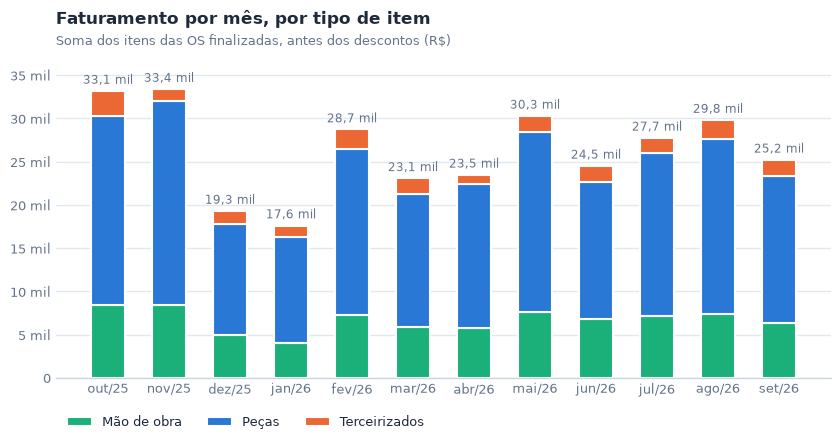

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.2))
base = pd.Series(0.0, index=mensal.index)
for coluna, nome in (("mao_de_obra", "Mão de obra"), ("pecas", "Peças"), ("terceiros", "Terceirizados")):
    ax.bar(rotulos, mensal[coluna], bottom=base, width=0.55, color=estilo.CORES_TIPO[nome], label=nome,
           edgecolor="white", linewidth=1.5)
    base += mensal[coluna]
for x, total in enumerate(base):
    ax.text(x, total + base.max() * 0.015, compacto(total), ha="center", va="bottom", fontsize=8.5,
            color=estilo.TEXTO_SUAVE)
ax.yaxis.set_major_formatter(estilo.EIXO_REAIS)
ax.set_ylim(0, base.max() * 1.12)
ax.set_title("Faturamento por mês, por tipo de item")
estilo.subtitulo(ax, "Soma dos itens das OS finalizadas, antes dos descontos (R$)")
ax.legend(ncols=3, loc="upper left", bbox_to_anchor=(0, -0.08))
plt.show()

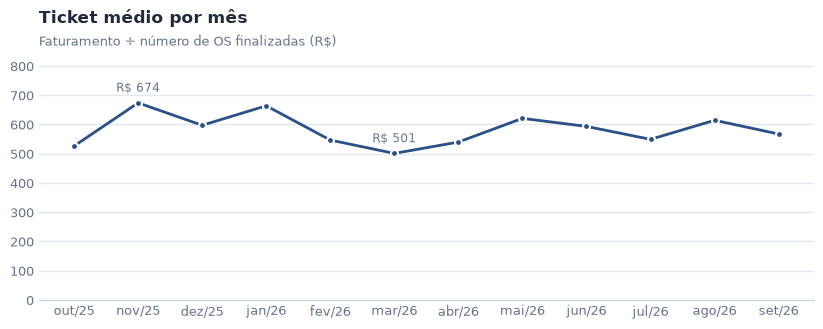

In [5]:
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(rotulos, mensal["ticket_medio"], color=estilo.NEUTRA, marker="o", markersize=5,
        markeredgecolor="white", markeredgewidth=1.5)
for indice in (mensal["ticket_medio"].values.argmin(), mensal["ticket_medio"].values.argmax()):
    valor = mensal["ticket_medio"].iloc[indice]
    ax.annotate(reais(valor, 0), (indice, valor), textcoords="offset points", xytext=(0, 8), ha="center",
                fontsize=8.5, color=estilo.TEXTO_SUAVE)
ax.yaxis.set_major_formatter(estilo.EIXO_REAIS)
ax.set_ylim(0, mensal["ticket_medio"].max() * 1.25)
ax.set_title("Ticket médio por mês")
estilo.subtitulo(ax, "Faturamento ÷ número de OS finalizadas (R$)")
plt.show()

In [6]:
forte, fraco = mensal["faturamento"].idxmax(), mensal["faturamento"].idxmin()
print(f"Melhor mês: {nome_mes(forte)} ({reais(mensal.loc[forte, 'faturamento'])})")
print(f"Pior mês:   {nome_mes(fraco)} ({reais(mensal.loc[fraco, 'faturamento'])})")
print(f"Correlação entre nº de OS e faturamento no mês: {mensal['os'].corr(mensal['faturamento']):.2f}")
print(f"Variação do ticket médio (desvio padrão / média): {pct(mensal['ticket_medio'].std() / mensal['ticket_medio'].mean(), 1)}")

Melhor mês: novembro de 2025 (R$ 33.026,00)
Pior mês:   janeiro de 2026 (R$ 17.261,00)
Correlação entre nº de OS e faturamento no mês: 0.89
Variação do ticket médio (desvio padrão / média): 9,3%


**Leitura.** O faturamento acompanha principalmente o **número de carros** (correlação de 0,89 entre OS e
faturamento no mês), enquanto o ticket médio varia pouco, cerca de 9% em torno da média. Para faturar mais, a
alavanca é volume (trazer carros nos meses fracos), mais do que aumentar o valor de cada serviço. As **peças** são
cerca de 2/3 do valor dos itens; a mão de obra, que é a base da comissão e quase toda margem da oficina, fica em
torno de um quarto.

## 2. Meses e dias da semana mais fortes

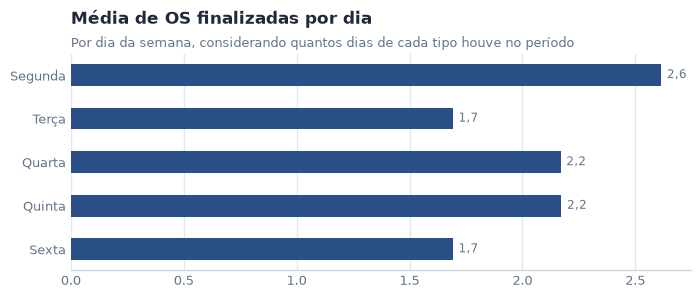

Segunda tem 35% mais OS que a média dos outros dias.


In [7]:
# Contar OS por dia da semana engana: um período pode ter mais segundas que sextas.
# O justo é a MÉDIA de OS por dia útil de cada tipo.
dias_uteis = pd.Series(pd.bdate_range(mensal.index.min(), FIM))
quantos_dias = dias_uteis.dt.dayofweek.value_counts()
nomes = ["Segunda", "Terça", "Quarta", "Quinta", "Sexta"]
por_dia = (finalizadas["data"].dt.dayofweek.value_counts() / quantos_dias).reindex(range(5))
por_dia.index = nomes

fig, ax = plt.subplots(figsize=(8, 2.8))
barras = ax.barh(nomes[::-1], por_dia[::-1], height=0.5, color=estilo.NEUTRA)
ax.bar_label(barras, labels=[f"{v:.1f}".replace(".", ",") for v in por_dia[::-1]], padding=4, fontsize=8.5,
             color=estilo.TEXTO_SUAVE)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.set_title("Média de OS finalizadas por dia")
estilo.subtitulo(ax, "Por dia da semana, considerando quantos dias de cada tipo houve no período")
plt.show()
print(f"Segunda tem {pct(por_dia['Segunda'] / por_dia.drop('Segunda').mean() - 1)} mais OS que a média dos outros dias.")

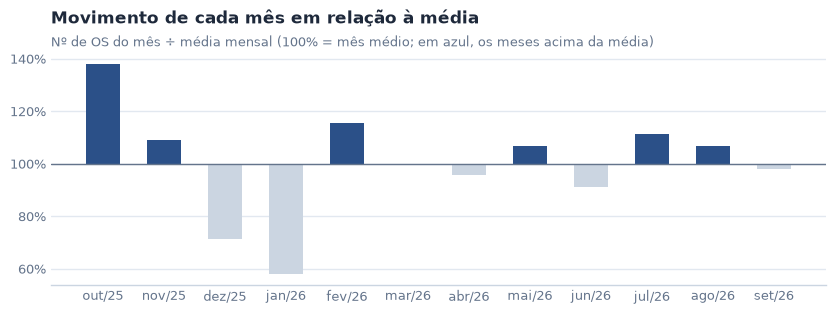

Janeiro de 2026: 42% abaixo da média
Dezembro de 2025: 29% abaixo da média


In [8]:
indice_mes = mensal["os"] / mensal["os"].mean()
fig, ax = plt.subplots(figsize=(10, 3))
cores = [estilo.NEUTRA if v >= 1 else estilo.APAGADA for v in indice_mes]
ax.bar(rotulos, indice_mes - 1, width=0.55, color=cores, bottom=1)
ax.axhline(1, color=estilo.TEXTO_SUAVE, linewidth=1)
ax.yaxis.set_major_formatter(estilo.EIXO_PCT)
ax.set_title("Movimento de cada mês em relação à média")
estilo.subtitulo(ax, "Nº de OS do mês ÷ média mensal (100% = mês médio; em azul, os meses acima da média)")
plt.show()
for mes_, valor in indice_mes.nsmallest(2).items():
    print(f"{nome_mes(mes_).capitalize()}: {pct(1 - valor)} abaixo da média")

**Leitura.** **Segunda-feira** é o dia mais movimentado, bem acima dos outros (são os carros que deram problema no
fim de semana); terça e sexta são os mais fracos. Vale ter a equipe completa na segunda e usar os dias mais
calmos para os serviços agendados. **Dezembro e janeiro** são os meses mais fracos (férias e fim de ano), um bom
momento para campanhas de revisão antes de viagem.

## 3. Quais itens trazem o dinheiro: curva ABC

In [9]:
from oficina.banco import normalizar_texto

itens["chave"] = itens["descricao"].str.strip().map(normalizar_texto)  # "Pivô " e "pivo" contam juntos
nomes_tipo = {"peca": "Peças", "mao_de_obra": "Mão de obra", "terceiros": "Terceirizados"}
abc = (itens.groupby(["chave", "tipo"])
       .agg(descricao=("descricao", "first"), vezes=("os_id", "nunique"), total=("total", "sum"))
       .reset_index().sort_values("total", ascending=False, ignore_index=True))
abc["tipo"] = abc["tipo"].map(nomes_tipo)
abc["participacao"] = abc["total"] / abc["total"].sum()
abc["acumulado"] = abc["participacao"].cumsum()
abc["classe"] = pd.cut(abc["acumulado"].shift(fill_value=0), [-1, 0.8, 0.95, 1], labels=["A", "B", "C"])

classe_a = abc[abc["classe"] == "A"]
print(f"{len(classe_a)} de {len(abc)} itens ({pct(len(classe_a) / len(abc))}) fazem 80% do valor vendido.")
print(f"Só os 3 primeiros fazem {pct(abc['acumulado'].iloc[2])}.")
estilo.tabela(classe_a[["descricao", "tipo", "vezes", "total", "participacao", "acumulado"]],
              reais_=["total"], pct_=["participacao", "acumulado"]).set_index("descricao")

14 de 26 itens (54%) fazem 80% do valor vendido.
Só os 3 primeiros fazem 34%.


,tipo,vezes,total,participacao,acumulado
descricao,,,,,
Amortecedor dianteiro,Peças,98,"R$ 55.000,00","17,4%","17,4%"
Amortecedor traseiro,Peças,64,"R$ 30.250,00","9,6%","27,0%"
Disco de freio,Peças,55,"R$ 22.510,00","7,1%","34,1%"
Alinhamento e balanceamento,Terceirizados,186,"R$ 21.790,00","6,9%","41,0%"
Bandeja de suspensão,Peças,60,"R$ 18.615,00","5,9%","46,9%"
Troca de amortecedor dianteiro,Mão de obra,98,"R$ 17.245,00","5,5%","52,3%"
Mola dianteira,Peças,35,"R$ 14.530,00","4,6%","56,9%"
Óleo do motor 5W30 (litro),Peças,76,"R$ 13.400,00","4,2%","61,2%"
Kit batente e coifa dianteiro,Peças,98,"R$ 12.500,00","4,0%","65,1%"


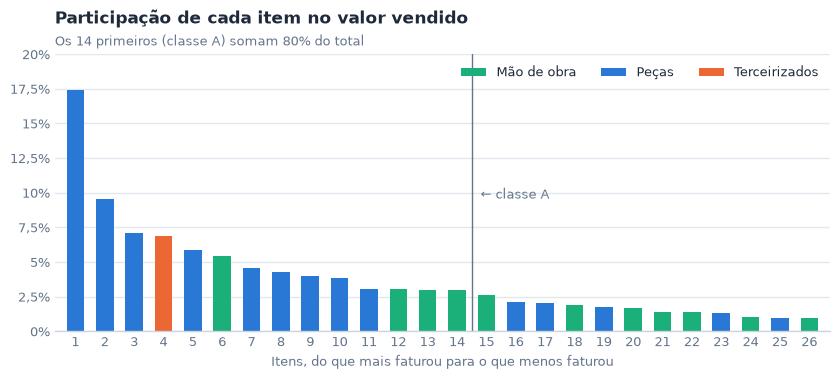

In [10]:
fig, ax = plt.subplots(figsize=(10, 3.6))
posicoes = range(1, len(abc) + 1)
cores = [estilo.CORES_TIPO[t] for t in abc["tipo"]]
ax.bar(posicoes, abc["participacao"], width=0.6, color=cores)
ax.yaxis.set_major_formatter(estilo.EIXO_PCT)
ax.set_xticks(list(posicoes))
ax.set_xlabel("Itens, do que mais faturou para o que menos faturou")
ax.set_title("Participação de cada item no valor vendido")
estilo.subtitulo(ax, f"Os {len(classe_a)} primeiros (classe A) somam 80% do total")
ax.axvline(len(classe_a) + 0.5, color=estilo.TEXTO_SUAVE, linewidth=1)
ax.text(len(classe_a) + 0.8, abc["participacao"].max() * 0.55, "← classe A", color=estilo.TEXTO_SUAVE, fontsize=9)
for nome, cor in estilo.CORES_TIPO.items():
    ax.bar(0, 0, color=cor, label=nome)
ax.set_xlim(0.3, len(abc) + 0.7)
ax.set_ylim(0, abc["participacao"].max() * 1.15)
ax.legend(ncols=3, loc="upper right")
plt.show()

**Leitura.** O dinheiro se concentra no topo: só o **amortecedor dianteiro** responde por quase um quinto do valor
vendido, e os três primeiros itens, por cerca de um terço. Os itens da **classe A** são os que não podem faltar no
estoque e os que mais merecem negociação com fornecedores: uma pequena melhora no preço de compra deles rende mais
do que em todos os outros juntos. O alinhamento (terceirizado) aparece entre os primeiros porque acompanha boa
parte das trocas de suspensão.

## 4. Mecânicos

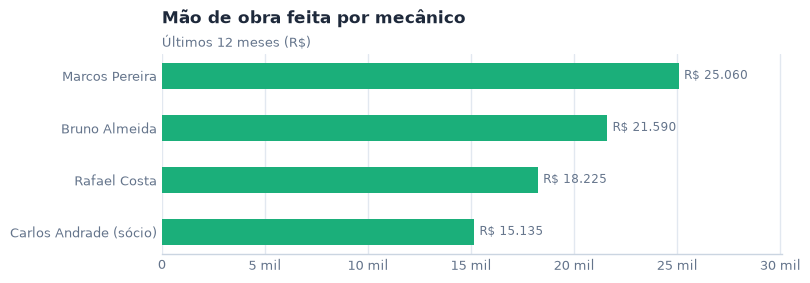

,os,mao_de_obra,faturamento,comissao,parte_das_os,mao_de_obra_por_os,comissao_sobre_mao
mecanico_nome,,,,,,,
Marcos Pereira,185,"R$ 25.060,00","R$ 95.291,00","R$ 7.518,00","34,3%","R$ 135,46","30,0%"
Bruno Almeida,143,"R$ 21.590,00","R$ 84.345,00","R$ 5.397,50","26,5%","R$ 150,98","25,0%"
Rafael Costa,119,"R$ 18.225,00","R$ 72.366,00","R$ 3.645,00","22,0%","R$ 153,15","20,0%"
Carlos Andrade (sócio),93,"R$ 15.135,00","R$ 60.280,00","R$ 0,00","17,2%","R$ 162,74","0,0%"


In [11]:
mecanicos = (finalizadas.groupby("mecanico_nome")
             .agg(os=("id", "size"), mao_de_obra=("total_mao_de_obra", "sum"), faturamento=("total", "sum"),
                  comissao=("comissao", "sum"))
             .sort_values("mao_de_obra", ascending=False))
mecanicos["parte_das_os"] = mecanicos["os"] / mecanicos["os"].sum()
mecanicos["mao_de_obra_por_os"] = mecanicos["mao_de_obra"] / mecanicos["os"]
mecanicos["comissao_sobre_mao"] = mecanicos["comissao"] / mecanicos["mao_de_obra"]

fig, ax = plt.subplots(figsize=(8, 2.6))
barras = ax.barh(mecanicos.index[::-1], mecanicos["mao_de_obra"][::-1], height=0.5, color=estilo.MAO_DE_OBRA)
ax.bar_label(barras, labels=[reais(v, 0) for v in mecanicos["mao_de_obra"][::-1]], padding=4, fontsize=8.5,
             color=estilo.TEXTO_SUAVE)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.xaxis.set_major_formatter(estilo.EIXO_REAIS)
ax.set_xlim(0, mecanicos["mao_de_obra"].max() * 1.2)
ax.set_title("Mão de obra feita por mecânico")
estilo.subtitulo(ax, "Últimos 12 meses (R$)")
plt.show()

estilo.tabela(mecanicos, reais_=["mao_de_obra", "faturamento", "comissao", "mao_de_obra_por_os"],
              pct_=["parte_das_os", "comissao_sobre_mao"])

**Leitura.** A diferença entre os mecânicos está na **quantidade de carros**, não no tamanho do serviço: a mão de
obra por OS é parecida para todos (entre R$ 135 e R$ 163). A comissão sai exatamente pelo percentual de cada um sobre a mão de obra, e o
**sócio (0%)** trabalha sem gerar comissão, como manda a regra do sistema.

## 5. Clientes: eles voltam?

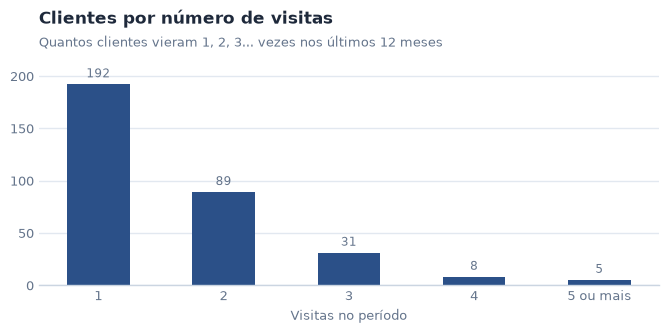

41% dos clientes voltaram e trouxeram 63% do faturamento.
Entre uma visita e outra, a mediana é de 75 dias.


,visitas,gasto
nome,,
Entregas Expressa ME,11,"R$ 8.249,00"
Transportes Rápido Ltda,9,"R$ 6.405,00"
Isabela Pinto,8,"R$ 4.455,00"
Frota Fácil Ltda,10,"R$ 4.195,00"
Isabela Souza,4,"R$ 3.194,00"


In [12]:
clientes = (finalizadas.groupby("cliente_id")
            .agg(nome=("cliente_nome", "first"), visitas=("id", "size"), gasto=("total", "sum"),
                 primeira=("data", "min"), ultima=("data", "max")))
faixas = pd.cut(clientes["visitas"], [0, 1, 2, 3, 4, 1000], labels=["1", "2", "3", "4", "5 ou mais"])
distribuicao = faixas.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 3))
barras = ax.bar(distribuicao.index.astype(str), distribuicao, width=0.5, color=estilo.NEUTRA)
ax.bar_label(barras, padding=3, fontsize=8.5, color=estilo.TEXTO_SUAVE)
ax.set_ylim(0, distribuicao.max() * 1.15)
ax.set_xlabel("Visitas no período")
ax.set_title("Clientes por número de visitas")
estilo.subtitulo(ax, "Quantos clientes vieram 1, 2, 3... vezes nos últimos 12 meses")
plt.show()

voltaram = clientes[clientes["visitas"] > 1]
intervalos = (finalizadas.sort_values("data").groupby("cliente_id")["data"].diff().dt.days.dropna())
print(f"{pct(len(voltaram) / len(clientes))} dos clientes voltaram e trouxeram "
      f"{pct(voltaram['gasto'].sum() / clientes['gasto'].sum())} do faturamento.")
print(f"Entre uma visita e outra, a mediana é de {intervalos.median():.0f} dias.")
estilo.tabela(clientes.sort_values("gasto", ascending=False).head(5)[["nome", "visitas", "gasto"]],
              reais_=["gasto"]).set_index("nome")

**Leitura.** Menos da metade dos clientes voltou no ano, mas esse grupo trouxe quase dois terços do faturamento.
As **frotas** (empresas) dominam o topo do ranking: são clientes para tratar com atenção especial (prazo, preço
combinado, prioridade na agenda). O intervalo típico entre visitas (cerca de dois meses e meio) ajuda a decidir
quando mandar uma mensagem lembrando da revisão.

## 6. Orçamentos: quantos viram OS?

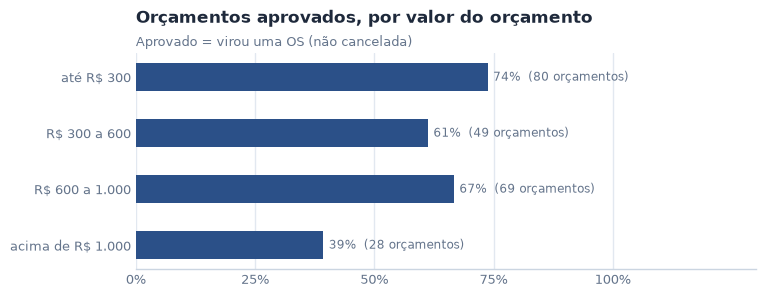

No geral, 65% dos 226 orçamentos viraram OS.


In [13]:
viraram_os = os_.loc[os_["orcamento_id"].notna() & (os_["status"] != "cancelada"), "orcamento_id"].astype(int)
orcamentos["aprovado"] = orcamentos["id"].isin(viraram_os)
faixas = [0, 300, 600, 1000, float("inf")]
nomes_faixa = ["até R$ 300", "R$ 300 a 600", "R$ 600 a 1.000", "acima de R$ 1.000"]
orcamentos["faixa"] = pd.cut(orcamentos["total"], faixas, labels=nomes_faixa)
conversao = orcamentos.groupby("faixa", observed=True)["aprovado"].agg(taxa="mean", orcamentos="size")

fig, ax = plt.subplots(figsize=(8, 2.8))
barras = ax.barh(conversao.index[::-1].astype(str), conversao["taxa"][::-1], height=0.5, color=estilo.NEUTRA)
ax.bar_label(barras, labels=[f"{pct(t)}  ({n} orçamentos)" for t, n in zip(conversao["taxa"][::-1],
                                                                           conversao["orcamentos"][::-1])],
             padding=4, fontsize=8.5, color=estilo.TEXTO_SUAVE)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.xaxis.set_major_formatter(estilo.EIXO_PCT)
ax.set_xlim(0, 1.3)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_title("Orçamentos aprovados, por valor do orçamento")
estilo.subtitulo(ax, "Aprovado = virou uma OS (não cancelada)")
plt.show()

print(f"No geral, {pct(orcamentos['aprovado'].mean())} dos {len(orcamentos)} orçamentos viraram OS.")

In [14]:
# Teste simples: a diferença entre orçamentos baratos e caros pode ser só acaso?
# Permutação: embaralha "aprovado" muitas vezes e vê com que frequência surge uma diferença tão grande.
import numpy as np

caros = orcamentos["total"] > 1000
diferenca = orcamentos.loc[~caros, "aprovado"].mean() - orcamentos.loc[caros, "aprovado"].mean()
gerador = np.random.default_rng(42)
aprovados = orcamentos["aprovado"].to_numpy()
simuladas = []
for _ in range(5000):
    embaralhado = gerador.permutation(aprovados)
    simuladas.append(embaralhado[~caros.to_numpy()].mean() - embaralhado[caros.to_numpy()].mean())
p_valor = (np.abs(simuladas) >= abs(diferenca)).mean()
print(f"Até R$ 1.000: {pct(orcamentos.loc[~caros, 'aprovado'].mean())} aprovados; "
      f"acima: {pct(orcamentos.loc[caros, 'aprovado'].mean())} (diferença de {diferenca * 100:.0f} pontos)")
print(f"p-valor da permutação: {p_valor:.4f}")

Até R$ 1.000: 68% aprovados; acima: 39% (diferença de 29 pontos)
p-valor da permutação: 0.0032


**Leitura.** Quanto mais caro o orçamento, menor a chance de o cliente aprovar, e o teste de permutação mostra que
essa diferença dificilmente é acaso. Para orçamentos acima de R$ 1.000 vale **ligar para o cliente** depois de
alguns dias, oferecer **parcelamento** ou dividir o serviço em etapas (o urgente agora, o resto depois).

## Conclusões

| Pergunta | O que os dados mostram | O que fazer |
|---|---|---|
| Faturamento | Cresce com o número de carros; o ticket médio é estável | Buscar volume nos meses fracos |
| Composição | Peças são a maior parte; mão de obra é cerca de 1/4 | Acompanhar a margem das peças da classe A |
| Calendário | Segunda é o dia mais forte; dezembro e janeiro, os mais fracos | Equipe completa na segunda; campanhas no fim de ano |
| Itens | 3 itens fazem cerca de 1/3 do valor vendido | Estoque e negociação focados na classe A |
| Mecânicos | Diferença está na quantidade de OS, não no tamanho | Distribuir melhor os carros quando houver fila |
| Clientes | 41% voltaram e trouxeram 63% do faturamento; frotas lideram | Lembrete de revisão pelo WhatsApp; atenção às frotas |
| Orçamentos | Os caros são aprovados com menos frequência | Retorno ativo e parcelamento acima de R$ 1.000 |

**Limitações.** Os dados são fictícios (gerados com padrões realistas, mas inventados). O sistema não guarda o
custo das peças, então ainda não dá para calcular margem de lucro. Seria o próximo campo a acrescentar.